#Import of libraries and generating datasets

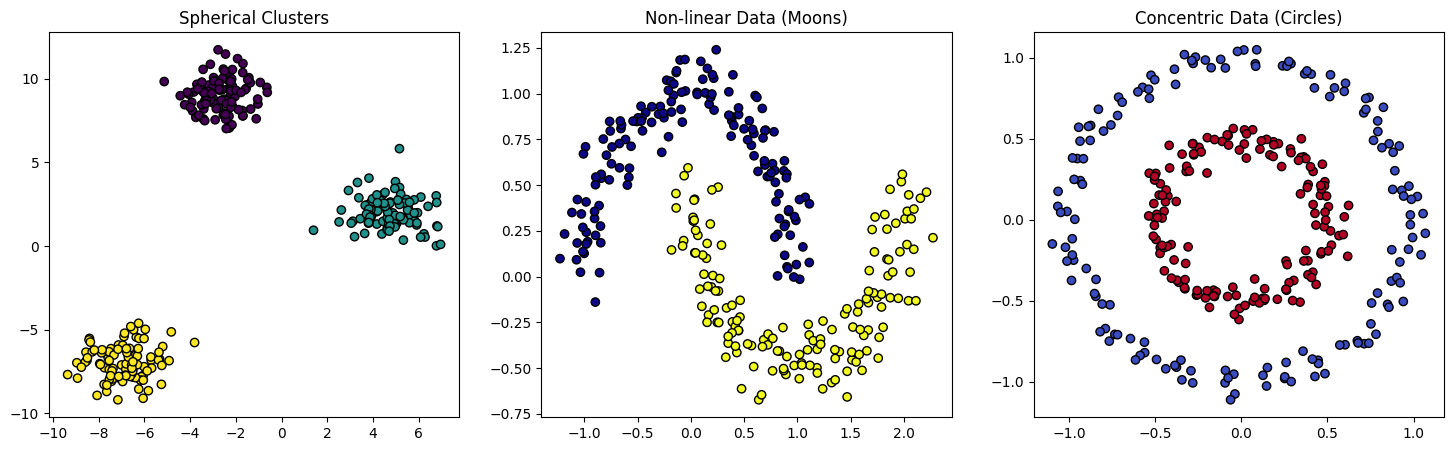

In [119]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 1. Spherical cluster data
X_spherical, y_spherical = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# 2. Non-linear data (Moons)
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

# 3. Concentric data (Circles)
X_circles, y_circles = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)

# Visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(X_spherical[:, 0], X_spherical[:, 1], c=y_spherical, cmap='viridis', edgecolors='k')
axs[0].set_title('Spherical Clusters')

axs[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='plasma', edgecolors='k')
axs[1].set_title('Non-linear Data (Moons)')

axs[2].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm', edgecolors='k')
axs[2].set_title('Concentric Data (Circles)')

plt.show()

In [120]:
def save_dataset_to_csv(X, y, filename):
    # Create a DataFrame from features and target
    df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
    df['target'] = y
    # Save to CSV
    df.to_csv(filename, index=False)
    print(f'Saved: {filename}')
    return df

# Save each dataset
df_spherical = save_dataset_to_csv(X_spherical, y_spherical, 'spherical_data.csv')
df_moons = save_dataset_to_csv(X_moons, y_moons, 'moons_data.csv')
df_circles = save_dataset_to_csv(X_circles, y_circles, 'circles_data.csv')

# Display the first few rows of one of them as a preview
display(df_spherical.head())

Saved: spherical_data.csv
Saved: moons_data.csv
Saved: circles_data.csv


,feature_1,feature_2,target
0,-7.338988,-7.729954,2
1,-7.740041,-7.264665,2
2,-1.686653,7.793442,0
3,4.422198,3.071947,1
4,-8.917752,-7.888196,2


In [121]:
dataset_spherical = pd.read_csv("spherical_data.csv")
dataset_moons = pd.read_csv("moons_data.csv")
dataset_circles = pd.read_csv("circles_data.csv")

In [122]:
X = dataset_spherical.iloc[:, :-1].values
y = dataset_spherical.iloc[:, -1].values

In [123]:
X1 = dataset_moons.iloc[:, :-1].values
y1 = dataset_moons.iloc[:, -1].values

In [124]:
X2 = dataset_circles.iloc[:, :-1].values
y2 = dataset_circles.iloc[:, -1].values

#K-means and it's results

In [125]:
#For Spherical Clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

In [126]:
#For Moons Clusters
kmeans1 = KMeans(n_clusters=2, init='k-means++', random_state=42)
y1_kmeans = kmeans1.fit_predict(X1)

In [127]:
#For Circles Clusters
kmeans2 = KMeans(n_clusters=2, init='k-means++', random_state=42)
y2_kmeans = kmeans2.fit_predict(X2)

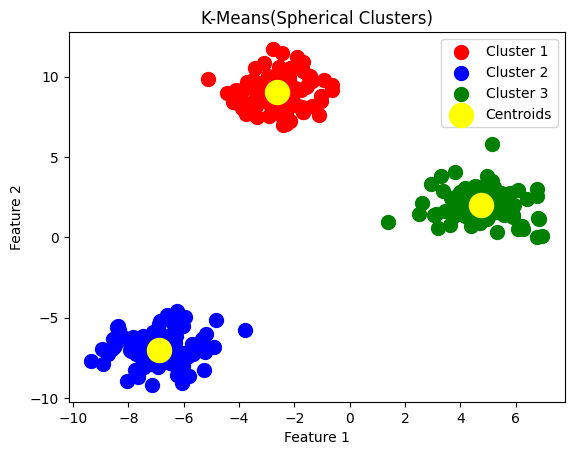

In [128]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title("K-Means(Spherical Clusters)")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

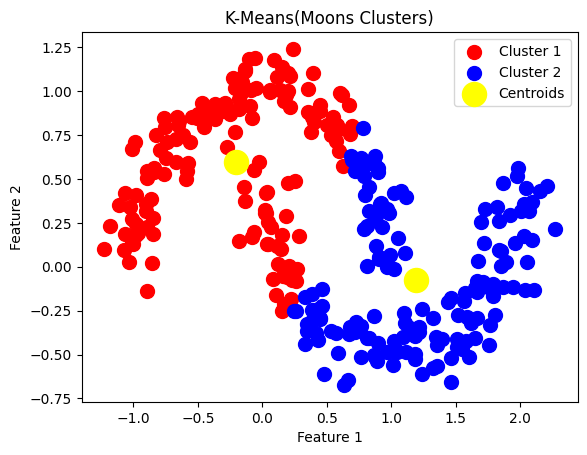

In [129]:
plt.scatter(X1[y1_kmeans == 0, 0], X1[y1_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X1[y1_kmeans == 1, 0], X1[y1_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(kmeans1.cluster_centers_[:, 0], kmeans1.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title("K-Means(Moons Clusters)")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

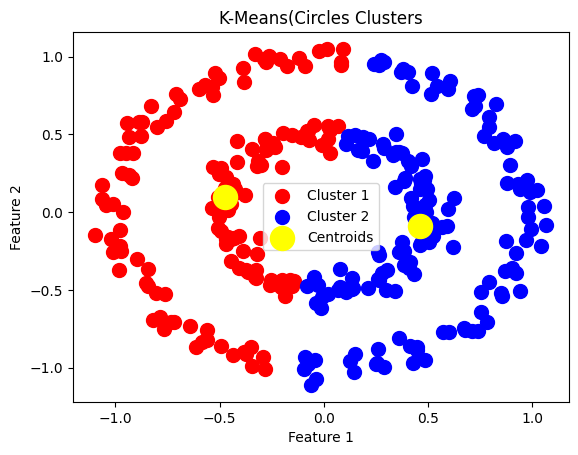

In [130]:
plt.scatter(X2[y2_kmeans == 0, 0], X2[y2_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X2[y2_kmeans == 1, 0], X2[y2_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(kmeans2.cluster_centers_[:, 0], kmeans2.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title("K-Means(Circles Clusters")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

#Hierarchical Clustering and it's results

In [131]:
#For Spherical Clusters
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

In [132]:
#For Moons Clusters
hc1 = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y1_hc = hc1.fit_predict(X1)

In [133]:
#For Circles Clusters
hc2 = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y2_hc = hc2.fit_predict(X2)

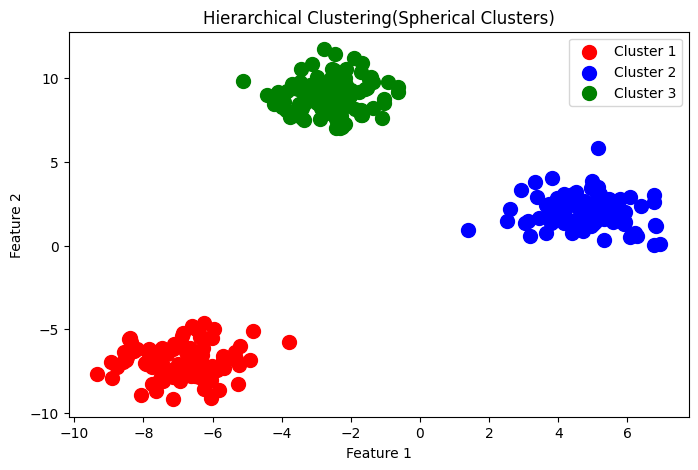

Silhouette Score for Spherical (K-Means): 0.848
Silhouette Score for Spherical (Hierarchical): 0.848


In [134]:
plt.figure(figsize=(8, 5))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s=100, c='green', label='Cluster 3')
plt.title('Hierarchical Clustering(Spherical Clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

#Quantitative comparison
score_kmeans = silhouette_score(X, y_kmeans)
score_hc = silhouette_score(X, y_hc)

print(f"Silhouette Score for Spherical (K-Means): {score_kmeans:.3f}")
print(f"Silhouette Score for Spherical (Hierarchical): {score_hc:.3f}")

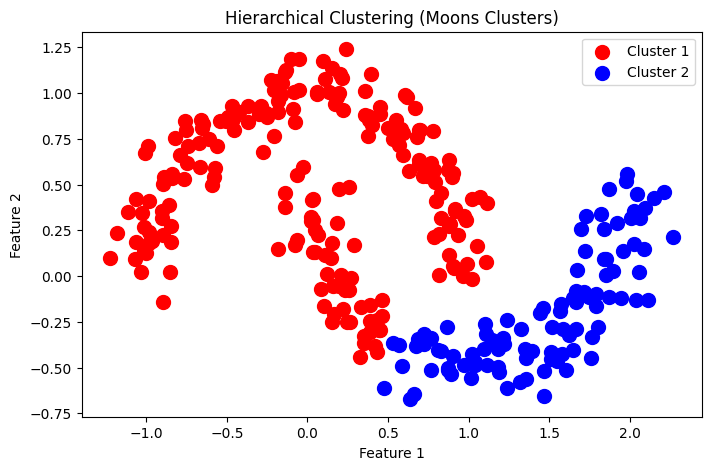

Silhouette Score for Moons (K-Means): 0.481
Silhouette Score for Moons (Hierarchical): 0.443


In [135]:
#Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X1[y1_hc == 0, 0], X1[y1_hc == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X1[y1_hc == 1, 0], X1[y1_hc == 1, 1], s=100, c='blue', label='Cluster 2')
plt.title('Hierarchical Clustering (Moons Clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

#Quantitative comparison
score_kmeans = silhouette_score(X1, y1_kmeans)
score_hc = silhouette_score(X1, y1_hc)

print(f"Silhouette Score for Moons (K-Means): {score_kmeans:.3f}")
print(f"Silhouette Score for Moons (Hierarchical): {score_hc:.3f}")

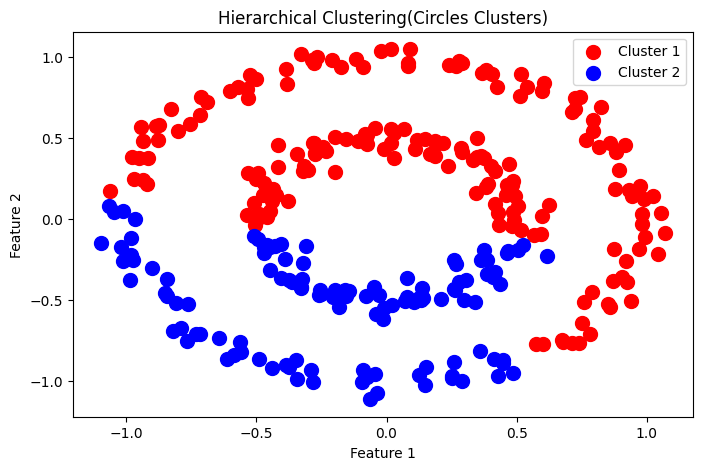

Silhouette Score for Circles (K-Means): 0.349
Silhouette Score for Circles (Hierarchical): 0.309


In [136]:
plt.figure(figsize=(8, 5))
plt.scatter(X2[y2_hc == 0, 0], X2[y2_hc == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X2[y2_hc == 1, 0], X2[y2_hc == 1, 1], s=100, c='blue', label='Cluster 2')
plt.title('Hierarchical Clustering(Circles Clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

#Quantitative comparison
score_kmeans = silhouette_score(X2, y2_kmeans)
score_hc = silhouette_score(X2, y2_hc)

print(f"Silhouette Score for Circles (K-Means): {score_kmeans:.3f}")
print(f"Silhouette Score for Circles (Hierarchical): {score_hc:.3f}")

#Results

In [137]:
results = []

#Data and labels mapping
datasets = [
    ('Spherical', X, y_kmeans, y_hc),
    ('Moons', X1, y1_kmeans, y1_hc),
    ('Circles', X2, y2_kmeans, y2_hc)
]

for name, data, km_labels, hc_labels in datasets:
    results.append({
        'Dataset': name,
        'K-Means Silhouette': silhouette_score(data, km_labels),
        'Hierarchical Silhouette': silhouette_score(data, hc_labels)
    })

#Create comparison table
df_comparison = pd.DataFrame(results)
display(df_comparison)

print("\n--- Conclusions ---")
print("1. Spherical: Both methods work perfectly (they are designed for convex shapes).")
print("2. Moons & Circles: NEITHER method works well. They fail on non-linear data.")
print("3. Note: Silhouette Score is misleading here. It mathematically favors spherical clusters, even if the result is visually wrong.")

,Dataset,K-Means Silhouette,Hierarchical Silhouette
0,Spherical,0.848030,0.848030
1,Moons,0.480504,0.442740
2,Circles,0.348947,0.308555



--- Conclusions ---
1. Spherical: Both methods work perfectly (they are designed for convex shapes).
2. Moons & Circles: NEITHER method works well. They fail on non-linear data.
3. Note: Silhouette Score is misleading here. It mathematically favors spherical clusters, even if the result is visually wrong.


#Testing of different Linkages

In [138]:
linkages = ['ward', 'complete', 'average']

print("--- Hierarchical Clustering Linkage Comparison ---")
for ds_name, data in [('Spherical', X), ('Moons', X1), ('Circles', X2)]:
    n_clus = 3 if ds_name == 'Spherical' else 2
    print(f"\nDataset: {ds_name}")

    best_linkage = ""
    best_score = -1

    for link in linkages:
        hc_test = AgglomerativeClustering(n_clusters=n_clus, metric='euclidean', linkage=link)
        y_pred = hc_test.fit_predict(data)
        score = silhouette_score(data, y_pred)

        print(f"Linkage: {link} | Silhouette Score: {score:.3f}")

        if score > best_score:
            best_score = score
            best_linkage = link

    print(f"-> BEST variant for {ds_name} is '{best_linkage.upper()}' (Score: {best_score:.3f})")

--- Hierarchical Clustering Linkage Comparison ---

Dataset: Spherical
Linkage: ward | Silhouette Score: 0.848
Linkage: complete | Silhouette Score: 0.848
Linkage: average | Silhouette Score: 0.848
-> BEST variant for Spherical is 'WARD' (Score: 0.848)

Dataset: Moons
Linkage: ward | Silhouette Score: 0.443
Linkage: complete | Silhouette Score: 0.428
Linkage: average | Silhouette Score: 0.457
-> BEST variant for Moons is 'AVERAGE' (Score: 0.457)

Dataset: Circles
Linkage: ward | Silhouette Score: 0.309
Linkage: complete | Silhouette Score: 0.231
Linkage: average | Silhouette Score: 0.313
-> BEST variant for Circles is 'AVERAGE' (Score: 0.313)


#Artficial Neural Network(ANN)

In [139]:
#Starting Hybrid ANN Phase

X_hybrid = np.column_stack((X1, y1_kmeans))

In [140]:
#Train test Split

X_train, X_test, y_train, y_test = train_test_split(X_hybrid, y1, test_size=0.2, random_state=42)

In [141]:
#Normalization of our data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [142]:
#Building architecture of ANN

ann_model = Sequential([
    Dense(units=16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1),
    Dense(units=8, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [143]:
#Compile model

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [144]:
#Training of our Neural Network

print("Training the ANN model to correct clustering mistakes...")
history = ann_model.fit(
    X_train_scaled, y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

Training the ANN model to correct clustering mistakes...


In [145]:
#Accuracy

loss, accuracy = ann_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n[Success] ANN Test Accuracy on Non-Linear Data: {accuracy * 100:.2f}%")


[Success] ANN Test Accuracy on Non-Linear Data: 96.67%


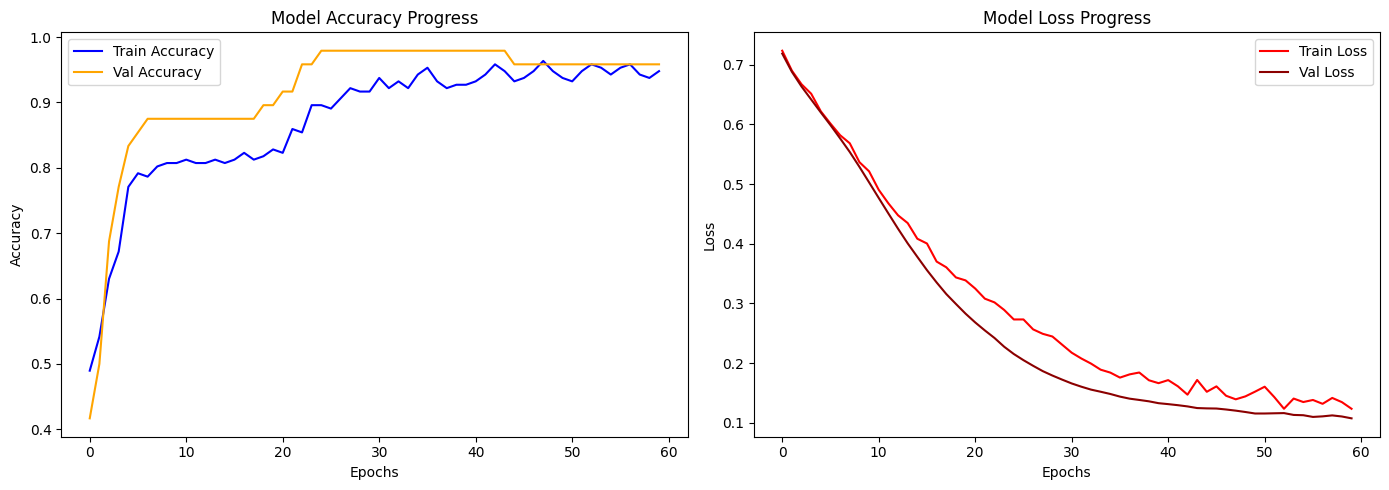

In [146]:
#Accuracy Scheme

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axs[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axs[0].set_title('Model Accuracy Progress')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

#Loss Scheme
axs[1].plot(history.history['loss'], label='Train Loss', color='red')
axs[1].plot(history.history['val_loss'], label='Val Loss', color='darkred')
axs[1].set_title('Model Loss Progress')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

In [147]:
#Final Consequence
print("\n--- Final Project Conclusion ---")
print("While traditional algorithms like K-Means failed geometrically on 'Moons',")
print(f"the hybrid ANN successfully learned the non-linear boundaries with {accuracy*100:.1f}% accuracy.")


--- Final Project Conclusion ---
While traditional algorithms like K-Means failed geometrically on 'Moons',
the hybrid ANN successfully learned the non-linear boundaries with 96.7% accuracy.
